Accuracy: 0.9666666666666667


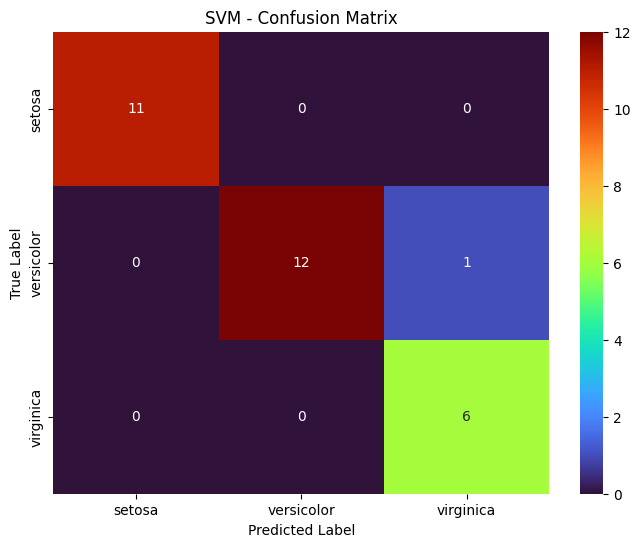

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Load Iris dataset
iris = load_iris()

# Create DataFrame
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['Species'] = iris.target

# Separate features and target
X = data.drop('Species', axis=1)
y = data['Species']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# Create and train SVM model
model = SVC(kernel='poly', random_state=1)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='turbo',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM - Confusion Matrix')
plt.show()